# Phase 1: Classic ML with Scikit-learn & Web Deployment

This notebook demonstrates a full MLOps Phase 1 workflow: exploratory data analysis, data preparation, model training with Scikit-learn, evaluation, and export to a JSON format for browser-side prediction via ML.js.

**Dataset**: Steam Store Games (~27,000 games)
**Problem**: Regression – predict the retail price of a Steam game based on 10 engineered features.
**Target variable**: `price` (EUR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json

## 1. Data Loading & Feature Engineering

We load the Steam dataset and engineer 10 binary and numeric features from raw columns.

In [2]:
df = pd.read_csv("steam.csv")
def has_term(val, target):
    if not isinstance(val, str): return 0
    return 1 if any(t.strip().lower() == target.lower() for t in val.split(';')) else 0

df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df['release_year'] = df['release_year'].fillna(df['release_year'].median())
df['self_published'] = (df['developer'] == df['publisher']).astype(int)
df['is_mac'] = df['platforms'].apply(lambda x: 1 if isinstance(x, str) and 'mac' in x.lower() else 0)
df['is_multiplayer'] = df['categories'].apply(lambda x: has_term(x, 'Multi-player'))
df['is_indie'] = df['genres'].apply(lambda x: has_term(x, 'Indie'))
df['is_action'] = df['genres'].apply(lambda x: has_term(x, 'Action'))
df['is_early_access'] = df['genres'].apply(lambda x: has_term(x, 'Early Access'))

features = [
    'average_playtime', 'achievements', 'release_year', 'self_published', 'english',
    'is_mac', 'is_multiplayer', 'is_indie',
    'is_action', 'is_early_access'
]
target = 'price'

df_clean = df.dropna(subset=features + [target])
df_clean = df_clean[(df_clean['price'] >= 4.0) & (df_clean['price'] <= 80.0)]
df_clean = df_clean[~((df_clean['price'] <= 6.0) & (df_clean['achievements'] > 50))]

print(f"Dataset shape after cleaning: {df_clean.shape}")
print(f"Price range: €{df_clean['price'].min():.2f} – €{df_clean['price'].max():.2f}")
df_clean[features + [target]].describe()

Dataset shape after cleaning: (12727, 25)
Price range: €4.00 – €79.99


,average_playtime,achievements,release_year,self_published,english,is_mac,is_multiplayer,is_indie,is_action,is_early_access,price
count,12727.000000,12727.000000,12727.00000,12727.000000,12727.000000,12727.000000,12727.000000,12727.000000,12727.000000,12727.000000,12727.000000
mean,171.067180,35.546319,2016.14646,0.589141,0.985071,0.338572,0.187004,0.635028,0.447081,0.140096,10.574090
std,1140.078512,288.627229,2.43057,0.492009,0.121273,0.473242,0.389930,0.481441,0.497211,0.347100,7.187402
min,0.000000,0.000000,1997.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,0.000000,0.000000,2015.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.190000
50%,0.000000,12.000000,2017.00000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,7.190000
75%,2.000000,28.000000,2018.00000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,11.990000
max,55204.000000,9821.000000,2019.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,79.990000


## 2. Exploratory Data Analysis (EDA)

Before training, we inspect the distribution of our target variable and the correlation structure of our features.

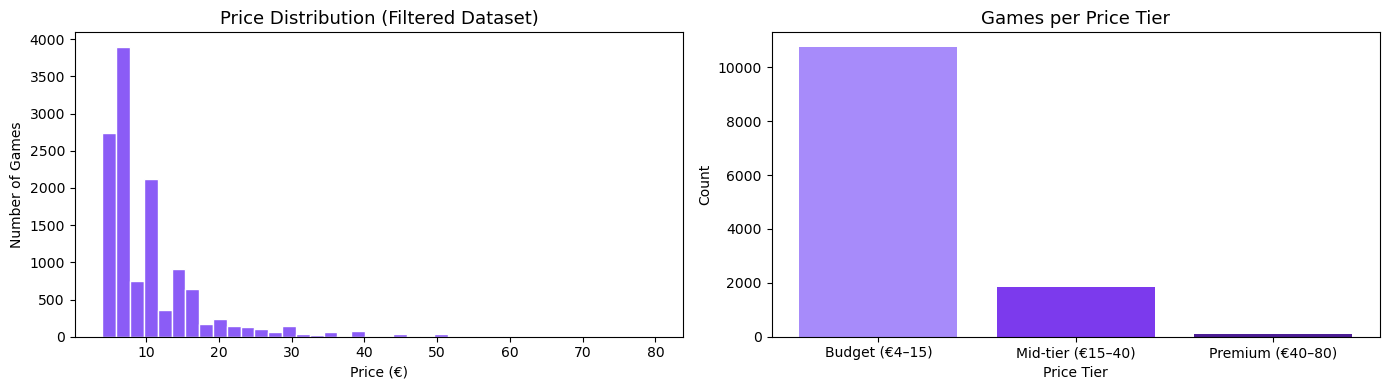

Most games cluster in the Budget tier (€4–15), confirming the strong indie presence on Steam.


In [3]:
# --- 2.1 Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean['price'], bins=40, color='#8b5cf6', edgecolor='white')
axes[0].set_title('Price Distribution (Filtered Dataset)', fontsize=13)
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Number of Games')

price_tier_counts = pd.cut(df_clean['price'], bins=[0, 15, 40, 80],
                            labels=['Budget (€4–15)', 'Mid-tier (€15–40)', 'Premium (€40–80)']).value_counts()
axes[1].bar(price_tier_counts.index, price_tier_counts.values, color=['#a78bfa', '#7c3aed', '#4c1d95'])
axes[1].set_title('Games per Price Tier', fontsize=13)
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Most games cluster in the Budget tier (€4–15), confirming the strong indie presence on Steam.")

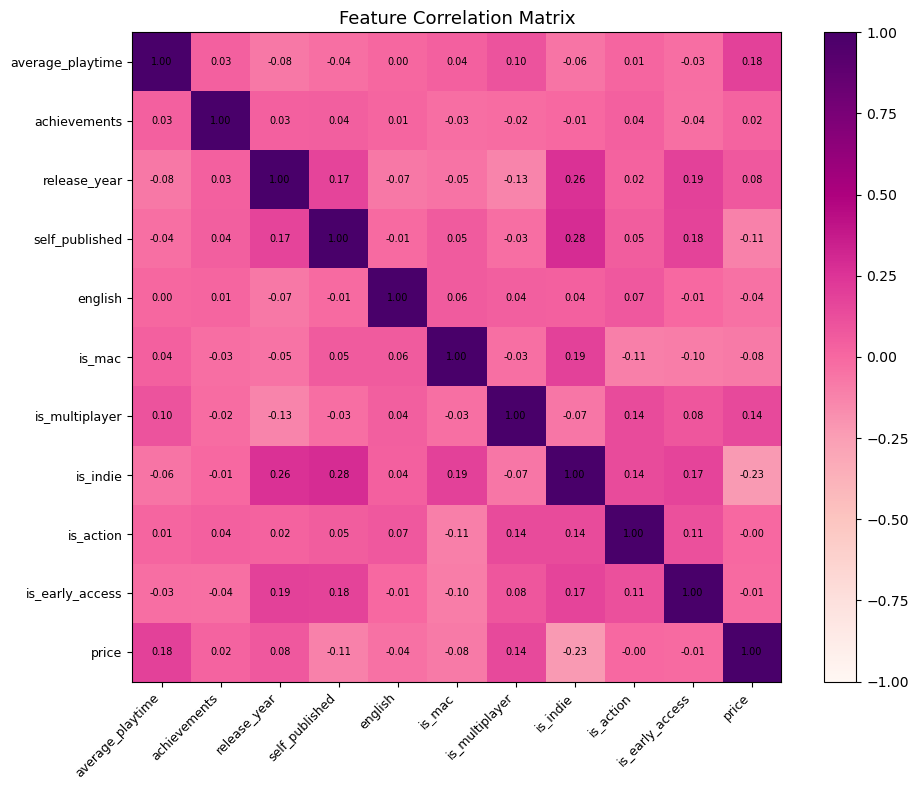

Key: is_indie is negatively correlated with price (indie games are cheaper).
average_playtime and achievements show mild positive correlation with price.


In [4]:
# --- 2.2 Correlation Heatmap ---
import matplotlib.colors as mcolors

corr = df_clean[features + [target]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.imshow(corr, cmap='RdPu', vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Key: is_indie is negatively correlated with price (indie games are cheaper).")
print("average_playtime and achievements show mild positive correlation with price.")

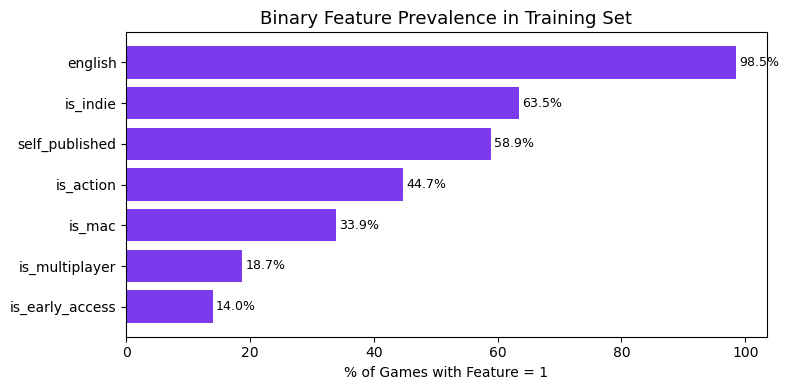

In [5]:
# --- 2.3 Binary Feature Prevalence ---
binary_features = ['self_published', 'english', 'is_mac', 'is_multiplayer',
                   'is_indie', 'is_action', 'is_early_access']
prevalence = df_clean[binary_features].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(prevalence.index, prevalence.values * 100, color='#7c3aed')
ax.set_xlabel('% of Games with Feature = 1')
ax.set_title('Binary Feature Prevalence in Training Set', fontsize=13)
for i, v in enumerate(prevalence.values):
    ax.text(v * 100 + 0.5, i, f'{v*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_feature_prevalence.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Model Training & Validation

We use a Stratified 80/20 split (stratified by price tier) to ensure all pricing tiers are represented in both train and test sets.

In [6]:
X = df_clean[features]
y = df_clean[target]
df_clean['price_tier'] = pd.cut(df_clean['price'], bins=[0, 15, 40, 100], labels=[1, 2, 3])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df_clean['price_tier'])
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} €")
print(f"R²:   {r2_score(y_test, y_pred):.3f}")

MAE:  4.52 €
RMSE: 6.67 €
R²:   0.102


## 4. Web Export API Generation

The trained Linear Regression model is exported as `model.json` so it can be loaded directly in the browser via `ML.js` without any server-side backend.

In [7]:
model_data = {
    "coef": model.coef_.tolist(),
    "intercept": float(model.intercept_),
    "feature_names": features
}
with open("model.json", "w") as f:
    json.dump(model_data, f)
print("model.json exported successfully.")
print(f"Features: {features}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients: {dict(zip(features, model.coef_.round(4)))}")


model.json exported successfully.
Features: ['average_playtime', 'achievements', 'release_year', 'self_published', 'english', 'is_mac', 'is_multiplayer', 'is_indie', 'is_action', 'is_early_access']
Intercept: -1063.7916
Coefficients: {'average_playtime': 0.001, 'achievements': 0.0002, 'release_year': 0.5349, 'self_published': -1.0511, 'english': -1.7395, 'is_mac': -0.3857, 'is_multiplayer': 2.554, 'is_indie': -3.5306, 'is_action': 0.1302, 'is_early_access': -0.1008}
